# Notebook to simulate and tune 5 qubit quantum chip

In [ ]:
from metal_flow.design import FOUR_QUBIT_DESIGN_DICT
from metal_flow.functions import create_design

from metal_flow.impedance import Sweeper_SYZ
from metal_flow.capcitive import Capacitence_Sweeper
from qiskit_metal import Dict


design = create_design(FOUR_QUBIT_DESIGN_DICT)




Generating Launchpads...
Generating CoupledLineTee
Connecting...
Generating Qubits...
Generating Readout Resonators...
Generating Couplers...


In [37]:
design.components['q_0'].options.pad_width = '427 um'
design.components['q_1'].options.pad_width = '375 um'
design.components.q_2.options.pad_width = '475 um'
print(design.components.q_2.options.pad_width)
design.rebuild()

475 um


INFO 05:05PM [connect_project]: Connecting to Ansys Desktop API...
INFO 05:05PM [load_ansys_project]: 	Opened Ansys App
INFO 05:05PM [load_ansys_project]: 	Opened Ansys Desktop v2025.1.4
INFO 05:05PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/DELL/Documents/Ansoft/
	Project:   Project301
INFO 05:05PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 05:05PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 05:05PM [connect]: 	Connected to project "Project301" and design "Design_q3d" 😀 

INFO 05:05PM [connect_design]: 	Opened active design
	Design:    Design_q3d [Solution type: Q3D]
INFO 05:05PM [get_setup]: 	Opened setup `sweep_Q3D`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 05:05PM [analyze]: Analyzing setup sweep_Q3D
INFO 05:11PM [get_matrix]: Exporting matrix data to (C:\Users\DELL\AppData\Local\Temp\tmp8vwp3j1l.txt, C, , sweep_Q3D:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 610000000

[3, 4] [5 0 1]
Predicted Values

Transmon Properties
f_Q 4.083084 [GHz]
EC 262.292596 [MHz]
EJ 9.073873 [GHz]
alpha -312.941229 [MHz]
dispersion 181.005667 [KHz]
Lq 18.000000 [nH]
Cq 73.849695 [fF]
T1 2105.399316 [us]

**Coupling Properties**

tCqbus1 2.964056 [fF]
gbus1_in_MHz 37.081808 [MHz]
χ_bus1 -0.092749 [MHz]
1/T1bus1 57.196209 [Hz]
T1bus1 2782.613482 [us]

tCqbus2 -4.030216 [fF]
gbus2_in_MHz -48.966802 [MHz]
χ_bus2 -0.183021 [MHz]
1/T1bus2 11.526378 [Hz]
T1bus2 13807.888073 [us]

tCqbus3 2.963680 [fF]
gbus3_in_MHz 34.993777 [MHz]
χ_bus3 -0.106751 [MHz]
1/T1bus3 6.871121 [Hz]
T1bus3 23162.877969 [us]
Bus-Bus Couplings
gbus1_2 2.849933 [MHz]
gbus1_3 2.146633 [MHz]
gbus2_3 2.690855 [MHz]
Is converged:True
Total passes:16


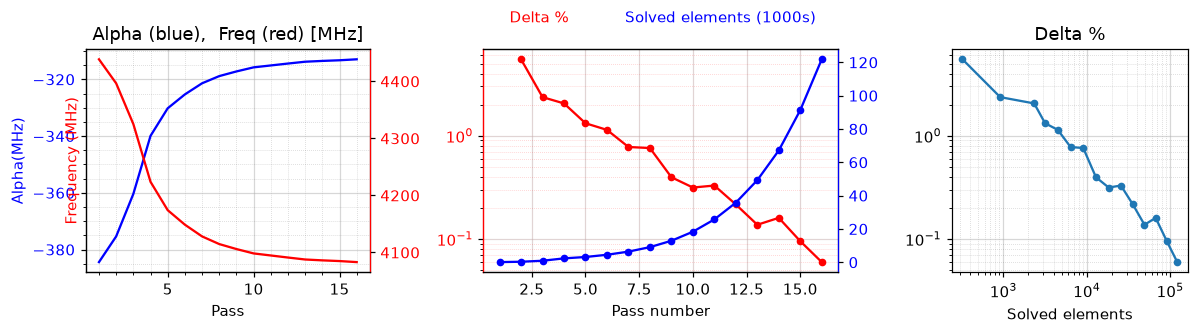

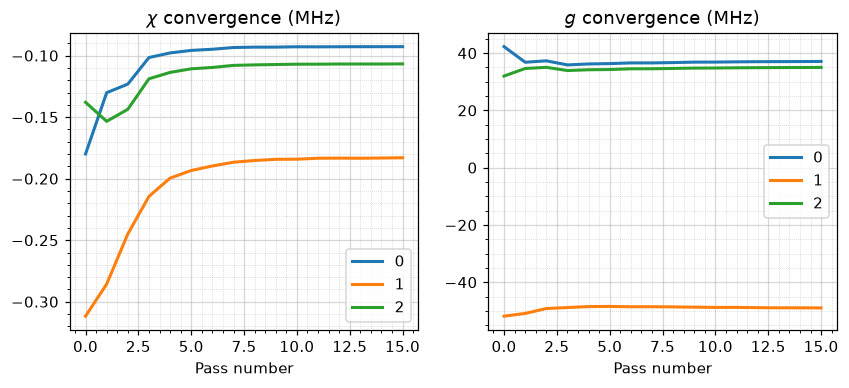

In [38]:

qubit_name = 'q_2'

def get_side_frequencies_for_qubit(design, qubit_name, DESIGN_DICT):

    qubit = qubit_name.replace('_', '')

    coupler_list = [freq for name, freq in DESIGN_DICT.coupler_frequencies_ghz.items() if qubit in name]

    return coupler_list


# print(get_side_frequencies_for_qubit(design, qubit_name, FOUR_QUBIT_DESIGN_DICT))


sweep_setup = Dict(design = design,
                            # Only simulate q0 and define its open terminations to extract exact capacitance matrix
                            run_args_dict = Dict(components=[design.components[qubit_name].name] , open_terminations=[(design.components[qubit_name].name, pad) for pad in design.components[qubit_name].pins.keys()]
                                                ),
                            # LOM physics constraints (Josephson Junction Inductance & Capacitance)
                            lom_setup = Dict(junctions=Dict(Lj=18, Cj=2),
                                             freq_readout=FOUR_QUBIT_DESIGN_DICT.resonator_frequencies_ghz[qubit_name], 
                                             freq_bus=get_side_frequencies_for_qubit(design, qubit_name, FOUR_QUBIT_DESIGN_DICT)
                                            ),
                            # Ansys Q3D Iterative solver properties
                            lom_sim_setup = Dict(name = 'sweep_Q3D', 
                                                 reuse_selected_design = True, 
                                                 reuse_setup = True, 
                                                 freq_ghz = FOUR_QUBIT_DESIGN_DICT.qubit_frequencies_hz[qubit_name], 
                                                 save_fields = False, 
                                                 enabled = True, 
                                                 max_passes = 35, 
                                                 min_passes = 2, 
                                                 min_converged_passes = 2, 
                                                 percent_error = 0.1, 
                                                 percent_refinement = 35, 
                                                 auto_increase_solution_order = True, 
                                                 solution_order = 'Highest', 
                                                 solver_type = 'Iterative'))


cap_sweep = Capacitence_Sweeper(sweep_setup)

latest_cap_matrix, all_cap_matrix, plot_freq_alpha_conv, plot_chi_coup = cap_sweep.perform_initial_analysis()


- Sweep which is optimized
- optimization class which is independent of the simulation used


- 

In [ ]:
cap_sweep.perform_sweep(name = f'pad_width_sweep', sweep_component_options = design.components.q0.options,
                                        sweep_variable = 'pad_width',
                                        sweep_values = [ str(450+(i*10))+'um' for i in range(-5, 6) ])

In [ ]:
import h5py
import numpy as np
import pandas as pd


def _decode_structured_array(arr: np.ndarray) -> pd.DataFrame:
    """
    Convert a numpy structured array (as written by to_records()) back into
    a DataFrame, decoding any bytes columns (from h5py |S storage) to str.
    """
    df = pd.DataFrame(arr)
    for col in df.columns:
        if df[col].dtype.kind == 'S':  # byte-string columns
            df[col] = df[col].str.decode('utf-8')
        elif df[col].dtype == object:
            # in case some values are bytes objects individually
            df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
    return df


def load_sweep_h5(h5_path: str) -> dict:
    """
    Reads a sweep .h5 file produced by Capacitence_Sweeper.perform_sweep()
    and returns a dict keyed by group name (e.g. 'pad_width_400um'), each
    containing:
        - 'capacitance_matrix': np.ndarray
        - 'cap_mat_all_passes': dict[str, np.ndarray]
        - 'iter_details': pd.DataFrame (1 row)
        - 'lom_details': pd.DataFrame
    """
    results = {}

    with h5py.File(h5_path, 'r') as f:
        for group_name in f.keys():
            group = f[group_name]

            entry = {}

            # Capacitance matrix (plain ndarray)
            entry['capacitance_matrix'] = group['capacitance_matrix'][:]

            # All-pass capacitance matrices (plain ndarrays, one per pass)
            cap_all_passes = {}
            if 'cap_mat_all_passes' in group:
                cap_group = group['cap_mat_all_passes']
                for pass_key in cap_group.keys():
                    cap_all_passes[pass_key] = cap_group[pass_key][:]
            entry['cap_mat_all_passes'] = cap_all_passes

            # iter_details (structured array -> DataFrame, decode strings)
            entry['iter_details'] = _decode_structured_array(group['iter_details'][:])

            # lom_details (structured array -> DataFrame, decode strings)
            entry['lom_details'] = _decode_structured_array(group['lom_details'][:])

            results[group_name] = entry

    return results


# --- Usage ---
data = load_sweep_h5('pad_width_sweep_data.h5')

# Example: build a single summary DataFrame across all sweep points
summary_rows = []
for group_name, entry in data.items():
    summary_rows.append(entry['iter_details'].iloc[0])

summary_df = pd.DataFrame(summary_rows).reset_index(drop=True)
summary_df